Problem 1a

In [4]:
import numpy as np

Q = np.matrix([[-1, 1, 0, 0],[0, -1, 1, 0], [0, 0, -1, 1], [1, 0, 0, -1]])

np.linalg.eigvals(Q)

array([-2.00000000e+00+0.j, -1.00000000e+00+1.j, -1.00000000e+00-1.j,
       -1.69628249e-16+0.j])

Problem 1d

In [5]:
import sympy as sp

t = sp.symbols('t')
y1 = sp.Function('y1')
y2 = sp.Function('y2')
y3 = sp.Function('y3')
y4 = sp.Function('y4')

eqs = [sp.Eq(sp.diff(y1(t), t), -y1(t) + y4(t)),
    sp.Eq(sp.diff(y2(t), t), y1(t) - y2(t)),
    sp.Eq(sp.diff(y3(t), t), y2(t) - y3(t)),
    sp.Eq(sp.diff(y4(t), t), y3(t) - y4(t))]

ics = {y1(0): sp.Rational(1, 3),
    y2(0): sp.Rational(2, 3),
    y3(0): 0,
    y4(0): 0}

sol = sp.dsolve(eqs, ics=ics)

for s in sol:
    print(s)

Eq(y1(t), 1/4 - exp(-t)*sin(t)/3 + exp(-t)*cos(t)/6 - exp(-2*t)/12)
Eq(y2(t), 1/4 + exp(-t)*sin(t)/6 + exp(-t)*cos(t)/3 + exp(-2*t)/12)
Eq(y3(t), 1/4 + exp(-t)*sin(t)/3 - exp(-t)*cos(t)/6 - exp(-2*t)/12)
Eq(y4(t), 1/4 - exp(-t)*sin(t)/6 - exp(-t)*cos(t)/3 + exp(-2*t)/12)


Problem 1e

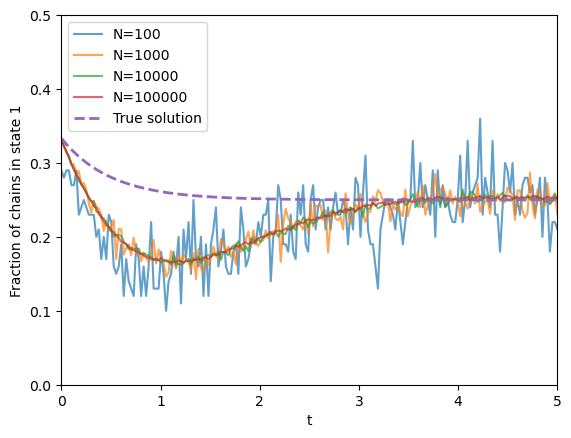

In [6]:
import matplotlib.pyplot as plt

def y1_true(t):
    return 1/4 + (1/12)*np.exp(-2*t)

def simulate_fraction_state1(N, t):
    f = np.zeros_like(t)

    initial_states = np.random.choice([1, 2], size=N, p=[1/3, 2/3])

    for i, t in enumerate(t):
        jumps = np.random.poisson(t, size=N)
        final_states = ((initial_states - 1 + jumps) % 4) + 1
        f[i] = np.mean(final_states == 1)

    return f

t = np.linspace(0, 5, 200)

Ns = [100, 1000, 10000, 100000]

for N in Ns:
    f = simulate_fraction_state1(N, t)
    plt.plot(t, f, label=f"N={N}", alpha=0.7)

plt.plot(t, y1_true(t), linewidth=2, linestyle='--', label="True solution")

plt.xlim(0, 5)
plt.ylim(0, 0.5)
plt.xlabel("t")
plt.ylabel("Fraction of chains in state 1")
plt.legend()
plt.show()

Problem 2c

In [ ]:
Q = sp.Matrix([[-2, 1, 1],[1, -1, 0], [1, 0, -1]])
sp.pretty_print((Q.T).eigenvects())

⎡⎛       ⎡⎡-2⎤⎤⎞  ⎛       ⎡⎡0 ⎤⎤⎞  ⎛      ⎡⎡1⎤⎤⎞⎤
⎢⎜       ⎢⎢  ⎥⎥⎟  ⎜       ⎢⎢  ⎥⎥⎟  ⎜      ⎢⎢ ⎥⎥⎟⎥
⎢⎜-3, 1, ⎢⎢1 ⎥⎥⎟, ⎜-1, 1, ⎢⎢-1⎥⎥⎟, ⎜0, 1, ⎢⎢1⎥⎥⎟⎥
⎢⎜       ⎢⎢  ⎥⎥⎟  ⎜       ⎢⎢  ⎥⎥⎟  ⎜      ⎢⎢ ⎥⎥⎟⎥
⎣⎝       ⎣⎣1 ⎦⎦⎠  ⎝       ⎣⎣1 ⎦⎦⎠  ⎝      ⎣⎣1⎦⎦⎠⎦


In [22]:
A = sp.Matrix([[-2, 0, 1], [1, -1, 1], [1,1,1]])
c1, c2, c3 = sp.symbols('c1 c2 c3')
x = sp.Matrix([c1, c2, c3])
b = sp.Matrix([0, 1, 0])
sp.solve(A*x-b, [c1,c2,c3])

{c1: 1/6, c2: -1/2, c3: 1/3}